In [1]:
import os
import mne
from mne import events_from_annotations, create_info, EpochsArray, concatenate_epochs, Epochs
import json
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import warnings
from collections import defaultdict
from eegkit.models import (
    TaskDTO, FilterParamsDTO, TimeDomainParamsDTO, PSDParamsDTO,
    EpochParamsDTO, TableInfoDTO, EpochPSDParamsDTO
)
from notebook_utils import reload_classes, reload_data_classes

warnings.filterwarnings("ignore", message=".*boundary.*data discontinuities.*")
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive, and thus cannot be shown")

In [2]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple, Union
import pandas as pd


# ---------- 1) Loader (debug-friendly) ----------

def get_participants_df(
    data_root: Union[str, Path],
    release: Union[str, int],
    *,
    normalize_cols: bool = True
) -> pd.DataFrame:
    """
    Load the participants.tsv for a given HBN-EEG FAIR release.

    Parameters
    ----------
    data_root : str | Path
        Root directory that contains cmi_bids_R{release}.
    release : str | int
        Release identifier, e.g. 9 or "R9".
    normalize_cols : bool
        If True, lowercases/strips column names.

    Returns
    -------
    pd.DataFrame
        Participants table as-is (or with normalized column names).
    """
    data_root = Path(data_root)
    rel_str = str(release)
    if not rel_str.startswith("R"):
        rel_str = f"R{rel_str}"
    bids_dir = data_root / f"cmi_bids_{rel_str}"
    pfile = bids_dir / "participants.tsv"

    if not pfile.exists():
        raise FileNotFoundError(f"participants.tsv not found at: {pfile}")

    df = pd.read_csv(pfile, sep="\t")
    if normalize_cols:
        df.columns = [c.strip().lower() for c in df.columns]
    return df


# ---------- 2) Filter (uses loader above) ----------

def filter_subjects(
    data_root: Union[str, Path],
    release: Union[str, int],
    *,
    age_range: Optional[Tuple[float, float]] = None,          # e.g. (5, 15)
    sex: Optional[Iterable[str]] = None,                      # e.g. {"M","F"} or {"F"}
    handedness: Optional[Iterable[str]] = None,               # e.g. {"R","L","A"}
    factor_ranges: Optional[Dict[str, Tuple[float, float]]] = None,  # {"p_factor":(0,2), ...}
    include_nan: bool = False,                                # keep NaNs when filtering
    limit: Optional[int] = None,                              # cap the number of subjects returned
    participants_df: Optional[pd.DataFrame] = None            # pass your own df to avoid reloading (debug)
) -> List[str]:
    """
    Return BIDS subject IDs ('sub-...') from HBN-EEG participants that match filters.

    You can pass a preloaded `participants_df` (e.g., from get_participants_df) to
    debug/inspect before filtering.
    """
    # Load (or reuse) participants
    df = participants_df if participants_df is not None else get_participants_df(data_root, release)
    cols = set(df.columns)

    # Identify subject id column
    id_col = next((c for c in ("participant_id", "subject_id", "sub_id", "id") if c in cols), None)
    if id_col is None:
        raise KeyError("Could not find a subject id column in participants.tsv (tried participant_id/subject_id/sub_id/id)")

    mask = pd.Series(True, index=df.index)

    # Age
    if age_range is not None:
        if "age" not in cols:
            raise KeyError("Age filter requested but 'age' column not found in participants.tsv")
        a_min, a_max = age_range
        m = df["age"].between(a_min, a_max)
        if include_nan:
            m |= df["age"].isna()
        mask &= m

    # Sex
    if sex is not None:
        if "sex" not in cols:
            raise KeyError("Sex filter requested but 'sex' column not found in participants.tsv")
        wanted = {s.upper() for s in sex}
        sx = df["sex"].astype(str).str.upper()
        m = sx.isin(wanted)
        if include_nan:
            m |= df["sex"].isna()
        mask &= m

    # Handedness
    if handedness is not None:
        if "handedness" not in cols:
            raise KeyError("Handedness filter requested but 'handedness' column not found in participants.tsv")
        wanted = {h.upper() for h in handedness}
        hd = df["handedness"].astype(str).str.upper()
        m = hd.isin(wanted)
        if include_nan:
            m |= df["handedness"].isna()
        mask &= m

    # Numeric factor ranges
    if factor_ranges:
        for col, (lo, hi) in factor_ranges.items():
            c = col.lower()
            if c not in cols:
                raise KeyError(f"Factor '{col}' not found in participants.tsv")
            m = df[c].between(lo, hi)
            if include_nan:
                m |= df[c].isna()
            mask &= m

    subs = df.loc[mask, id_col].astype(str).tolist()
    subs = [s if s.startswith("sub-") else f"sub-{s}" for s in subs]
    if limit is not None:
        subs = subs[:limit]
    return subs


# ---------- 3) (Optional) helper: age binning for grouping ----------

def add_age_bin(
    participants_df: pd.DataFrame,
    *,
    bins: Tuple[float, ...] = (5, 10, 15, 21),
    labels: Tuple[str, ...] = ("5-10", "11-15", "16-21"),
    column_name: str = "age_bin"
) -> pd.DataFrame:
    """
    Return a copy of participants_df with an 'age_bin' categorical column for grouping.
    """
    df = participants_df.copy()
    if "age" not in df.columns:
        raise KeyError("'age' column not found to create bins")
    df[column_name] = pd.cut(df["age"], bins=bins, labels=labels, include_lowest=True, right=True)
    return df


In [3]:
data_root = "/mount/NAS-public-dataset/HBN-EEG"
release = 1

# 1) load & inspect (debug here freely)
p = get_participants_df(data_root, release)
print(p.head())
print(p.columns)

     participant_id release_number sex      age  ehq_total commercial_use  \
0  sub-NDARAC904DMU             R1   F  11.3386      71.17            Yes   
1  sub-NDARAG143ARJ             R1   M   7.6648     100.05            Yes   
2  sub-NDARAM704GKZ             R1   M  10.9449     -53.36            Yes   
3  sub-NDARAN385MDH             R1   M  10.7089      96.72            Yes   
4  sub-NDARAP359UM6             R1   F  12.8422      80.04            Yes   

  full_pheno  p_factor  attention  internalizing  ...  thepresent  \
0        Yes    -0.603     -0.446          1.248  ...   available   
1        Yes    -0.258     -0.425          1.006  ...   available   
2        Yes     0.062     -0.119          0.222  ...   available   
3        Yes     0.034     -0.308          0.455  ...   available   
4        Yes     0.467      1.826          1.949  ...   available   

  diaryofawimpykid contrastchangedetection_1 contrastchangedetection_2  \
0        available                 available    

In [4]:
row = p.loc[p["participant_id"] == "sub-NDARMD575AXD"].iloc[0]
print(row)

participant_id               sub-NDARMD575AXD
release_number                             R1
sex                                         M
age                                    6.0545
ehq_total                               73.37
commercial_use                            Yes
full_pheno                                Yes
p_factor                                 0.22
attention                              -0.368
internalizing                          -0.811
externalizing                            1.11
restingstate                        available
despicableme                        available
funwithfractals                     available
thepresent                        unavailable
diaryofawimpykid                  unavailable
contrastchangedetection_1             caution
contrastchangedetection_2             caution
contrastchangedetection_3         unavailable
surroundsupp_1                      available
surroundsupp_2                    unavailable
seqlearning6target                

In [5]:
age_filter = (p["age"] >= 5) & (p["age"] <= 6)

# filter surround support availability
surround_filter = (p["surroundsupp_1"] == "available") | (p["surroundsupp_2"] == "available")

# combine
result = p[age_filter & surround_filter]

print(result)

       participant_id release_number sex     age  ehq_total commercial_use  \
42   sub-NDARGL800LDW             R1   M  5.1620      13.34            Yes   
135  sub-NDARZX561DR9             R1   M  5.9943     100.05            Yes   

    full_pheno  p_factor  attention  internalizing  ...  thepresent  \
42         Yes    -0.662     -0.882         -0.924  ...   available   
135        Yes     0.814      1.978          0.207  ...   available   

    diaryofawimpykid contrastchangedetection_1 contrastchangedetection_2  \
42       unavailable                 available                 available   
135        available               unavailable               unavailable   

    contrastchangedetection_3 surroundsupp_1 surroundsupp_2  \
42                  available      available      available   
135               unavailable      available      available   

    seqlearning6target seqlearning8target symbolsearch  
42         unavailable        unavailable    available  
135          avail

In [6]:
# 2) filter, using the loaded df (no re-read)
subs_5_10 = filter_subjects(
    data_root, release,
    age_range=(5, 10),
    participants_df=p
)

# 3) add age bins for later grouping
p_binned = add_age_bin(p)
p_binned[["participant_id", "age", "age_bin"]].head()

,participant_id,age,age_bin
0,sub-NDARAC904DMU,11.3386,11-15
1,sub-NDARAG143ARJ,7.6648,5-10
2,sub-NDARAM704GKZ,10.9449,11-15
3,sub-NDARAN385MDH,10.7089,11-15
4,sub-NDARAP359UM6,12.8422,11-15


In [7]:
import pandas as pd
from pathlib import Path

# Path to Release 1 participants.tsv
p = Path("/mount/NAS-public-dataset/HBN-EEG/cmi_bids_R1/participants.tsv")

df = pd.read_csv(p, sep="\t")

# Normalize column names to lower for safety
df.columns = [c.lower() for c in df.columns]

# Define the two surround suppression columns
cols = [c for c in df.columns if c.startswith("surroundsupp")]

# Count subjects with either surroundSupp_1 OR surroundSupp_2 available
mask = df[cols].apply(lambda row: row.astype(str).str.lower().eq("available").any(), axis=1)

n_subjects = mask.sum()
print(f"Number of subjects in Release 1 with surroundSupp_1 or surroundSupp_2 available: {n_subjects}")

# (Optional) list their IDs
subjects = df.loc[mask, "participant_id"].tolist()
print("Example subject IDs:", subjects[:10])


Number of subjects in Release 1 with surroundSupp_1 or surroundSupp_2 available: 110
Example subject IDs: ['sub-NDARAC904DMU', 'sub-NDARAG143ARJ', 'sub-NDARAM704GKZ', 'sub-NDARAN385MDH', 'sub-NDARAP359UM6', 'sub-NDARAW320CGR', 'sub-NDARBD879MBX', 'sub-NDARBH024NH2', 'sub-NDARBK082PDD', 'sub-NDARBM173BJG']


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- config ----------
RELEASES = range(11)  # 0..10
BASE_TPL = "/mount/NAS-public-dataset/HBN-EEG/cmi_bids_R{release}/participants.tsv"
OUT_CSV  = "hbn_eeg_participants_combined_R0_R10.csv"

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Robustly extract/normalize age (years) and sex columns across possible names/encodings."""
    # age
    age_candidates = ["age", "age_years", "age_at_session", "ageAtSession",
                      "participant_age", "Age"]
    age_col = next((c for c in age_candidates if c in df.columns), None)
    if age_col is None:
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        age_col = next((c for c in numeric_cols if "age" in c.lower()), None)
    df["age_years_norm"] = pd.to_numeric(df[age_col], errors="coerce") if age_col else np.nan

    # sex
    sex_candidates = ["sex", "gender", "Sex", "Gender", "biological_sex", "participant_sex"]
    sex_col = next((c for c in sex_candidates if c in df.columns), None)
    if sex_col is None:
        obj_cols = [c for c in df.columns if df[c].dtype == "object"]
        sex_col = next((c for c in obj_cols if "sex" in c.lower() or "gender" in c.lower()), None)

    def norm_sex(x):
        if pd.isna(x):
            return None
        s = str(x).strip().lower()
        if s in {"m", "male", "man", "boy", "1"}: return "Male"
        if s in {"f", "female", "woman", "girl", "2"}: return "Female"
        return "Other/NA"

    df["sex_norm"] = df[sex_col].map(norm_sex) if sex_col else pd.Series([None] * len(df), dtype="object")
    return df

# ---------- load ----------
dfs = []
for r in RELEASES:
    p = Path(BASE_TPL.format(release=r))
    if not p.exists():
        continue
    try:
        df = pd.read_csv(p, sep="\t")
    except Exception:
        try:
            df = pd.read_csv(p, sep=",")
        except Exception:
            df = pd.read_csv(p, delim_whitespace=True)
    df["release"] = r
    dfs.append(normalize_columns(df))

if not dfs:
    raise FileNotFoundError("No participants.tsv found in any of R0..R10. Check BASE_TPL path or mount.")

p = pd.concat(dfs, ignore_index=True)


In [4]:
import pandas as pd

bins = list(range(5, 23))  
labels = [f"{i}-{i+1}" for i in bins[:-1]]

# Create binned column
p["age_bin"] = pd.cut(p["age"], bins=bins, labels=labels, right=False)

# Count participants by release_number and age_bin
count_table = (
    p.groupby(["release_number", "age_bin"])
     .size()
     .unstack(fill_value=0)   # makes columns = age bins
     .sort_index(axis=1)      # keep bins in order
)

count_table

/tmp/ipykernel_789309/3193522714.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p.groupby(["release_number", "age_bin"])


age_bin,5-6,6-7,7-8,8-9,9-10,10-11,11-12,12-13,13-14,14-15,15-16,16-17,17-18,18-19,19-20,20-21,21-22
release_number,,,,,,,,,,,,,,,,,
R1,9,16,15,14,21,10,10,7,9,9,7,5,0,1,2,0,1
R2,18,18,17,21,16,13,13,8,9,5,3,4,2,3,0,0,0
R3,20,17,25,21,17,18,20,11,13,5,4,5,4,1,1,2,0
R4,30,36,45,32,32,25,27,21,17,14,16,16,8,1,3,1,0
R5,19,32,33,39,45,39,32,17,15,17,14,11,10,2,2,3,0
R6,9,14,12,18,19,7,14,3,11,8,6,5,2,2,3,1,1
R7,17,44,40,42,49,30,38,33,25,12,8,14,17,3,3,3,3
R8,18,30,35,34,26,33,13,16,18,12,7,6,3,3,0,0,3
R9,12,36,30,48,43,41,17,20,18,8,10,5,5,1,1,0,0


/tmp/ipykernel_1614053/804462117.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Sex")


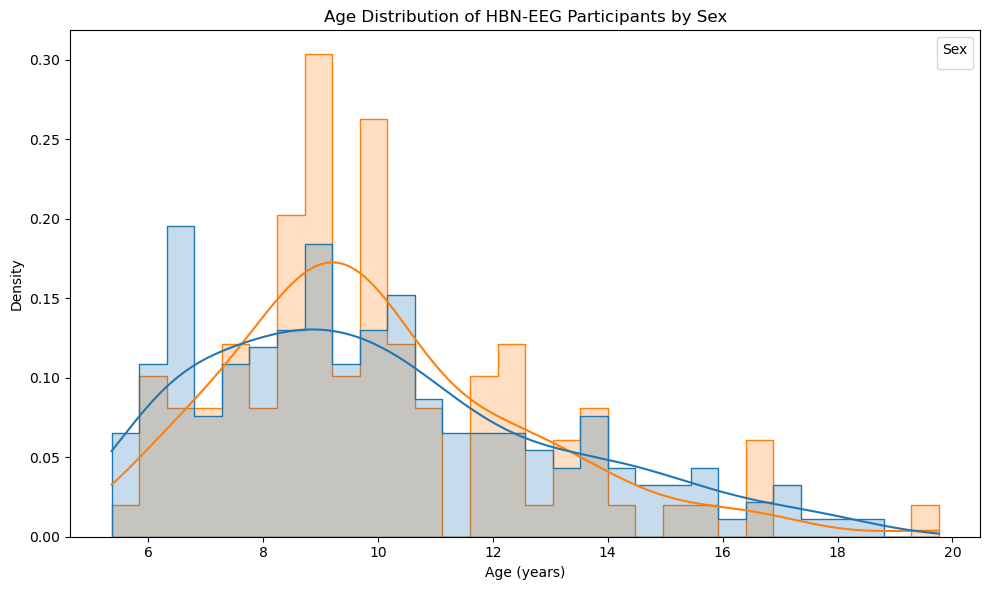

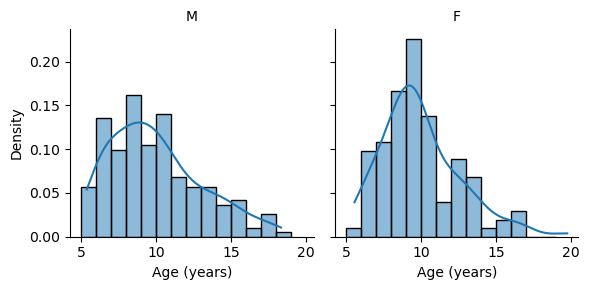

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="age",
    hue="sex",       # separate by sex
    bins=30,
    kde=True,        # adds smooth curve
    element="step",  # clean overlay style
    stat="density",  # normalize to density
    common_norm=False
)

plt.title("Age Distribution of HBN-EEG Participants by Sex")
plt.xlabel("Age (years)")
plt.ylabel("Density")
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot, col="sex", col_wrap=2, sharex=True, sharey=True)
g.map_dataframe(
    sns.histplot,
    x="age",
    bins=range(int(df_plot["age"].min()), int(df_plot["age"].max()) + 1),
    kde=True,
    stat="density"
)
g.set_axis_labels("Age (years)", "Density")
g.set_titles(col_template="{col_name}")
plt.show()

/tmp/ipykernel_1614053/2329188212.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Sex")


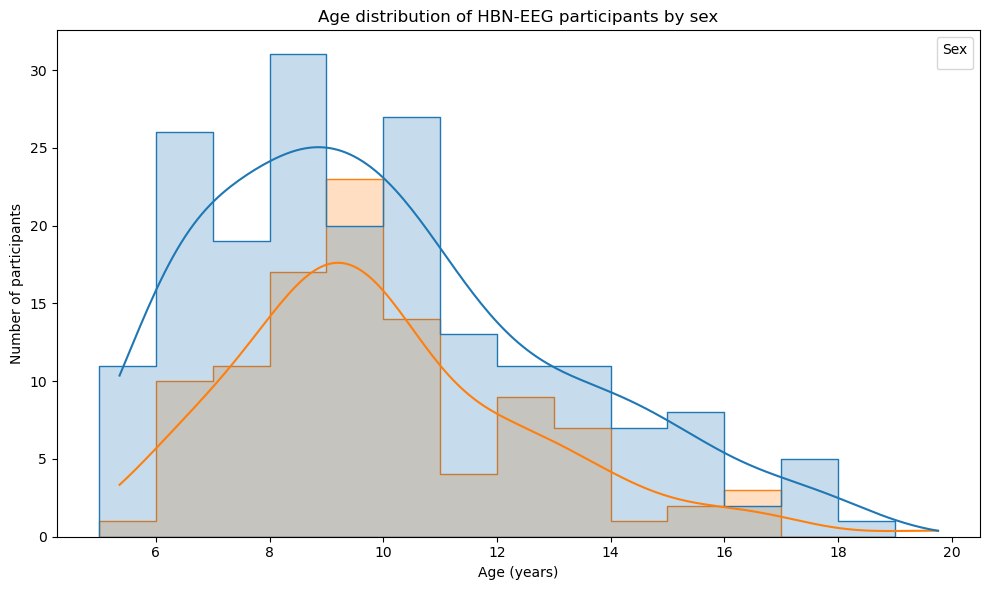

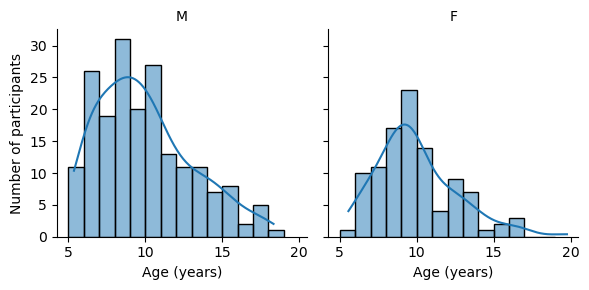

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# df must have columns: "age" (float, in years), "sex" (Male/Female/Other)
df_plot = df.dropna(subset=["age"])

# Combined histogram + KDE, grouped by sex, showing counts
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_plot,
    x="age",
    hue="sex",
    bins=range(int(df_plot["age"].min()), int(df_plot["age"].max()) + 1),  # 1-year bins
    kde=True,
    element="step",
    stat="count",   # <-- show amount, not density
    common_norm=False
)
plt.title("Age distribution of HBN-EEG participants by sex")
plt.xlabel("Age (years)")
plt.ylabel("Number of participants")
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

# Facet histograms by sex (subplots with counts)
g = sns.FacetGrid(df_plot, col="sex", col_wrap=2, sharex=True, sharey=True)
g.map_dataframe(
    sns.histplot,
    x="age",
    bins=range(int(df_plot["age"].min()), int(df_plot["age"].max()) + 1),
    kde=True,
    stat="count"
)
g.set_axis_labels("Age (years)", "Number of participants")
g.set_titles(col_template="{col_name}")
plt.show()


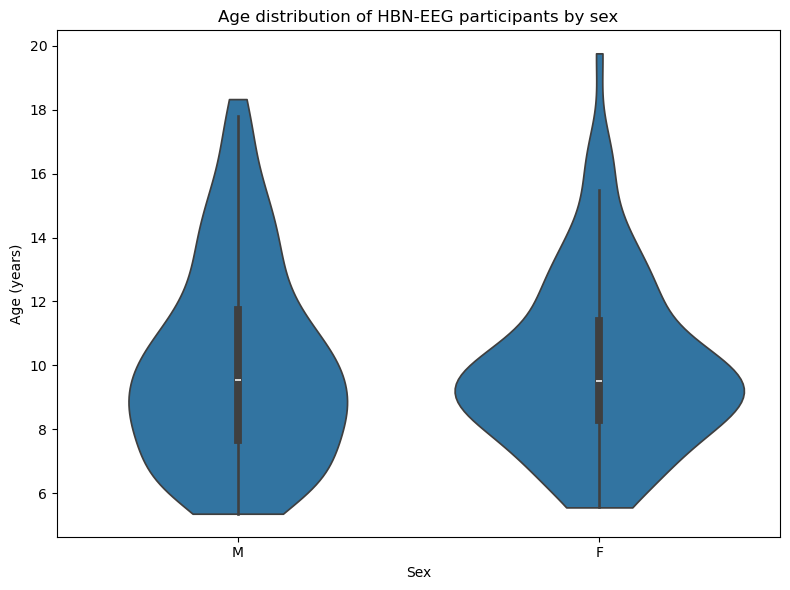

In [13]:
# df must have columns: "age" (float, in years), "sex" (Male/Female/Other)
df_plot = df.dropna(subset=["age"])

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df_plot,
    x="sex",
    y="age",
    inner="box",   # adds a mini boxplot inside the violin
    cut=0          # trims tails to actual min/max
)
plt.title("Age distribution of HBN-EEG participants by sex")
plt.xlabel("Sex")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()


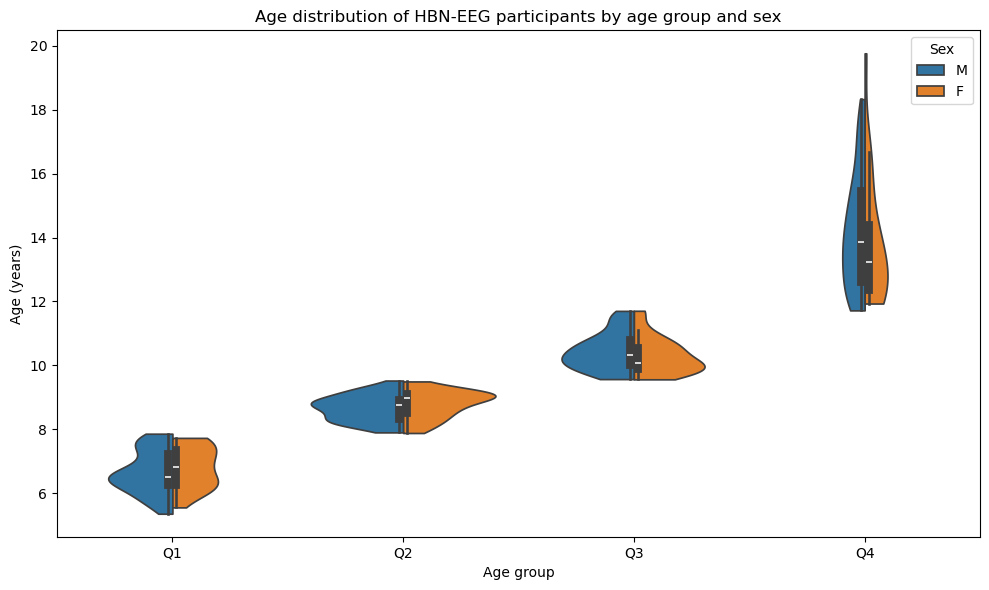

In [14]:
# df must have ["age", "sex"]
df_plot = df.dropna(subset=["age"]).copy()

# Define 4 age groups (quartiles or fixed bins)
# Option A: quartiles
df_plot["age_group"] = pd.qcut(df_plot["age"], 4, labels=["Q1","Q2","Q3","Q4"])

# Option B: fixed ranges (example: childhood, pre-teen, teen, young adult)
# df_plot["age_group"] = pd.cut(df_plot["age"], 
#                               bins=[5, 9, 13, 17, 22], 
#                               labels=["5–9","10–13","14–17","18–21"])

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_plot,
    x="age_group",
    y="age",
    hue="sex",
    split=True,    # show male/female side by side in one violin
    inner="box",
    cut=0
)
plt.title("Age distribution of HBN-EEG participants by age group and sex")
plt.xlabel("Age group")
plt.ylabel("Age (years)")
plt.legend(title="Sex")
plt.tight_layout()
plt.show()
